In [3]:
import os
import gc
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import kagglehub

In [4]:
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 64

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

strategy = tf.distribute.MirroredStrategy()
tf.keras.mixed_precision.set_global_policy("mixed_float16")

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))
print("GPUs being used:", strategy.num_replicas_in_sync)
print("Precision policy:", tf.keras.mixed_precision.global_policy())

print("\nExperiment: ResNet50 Feature-Level SMOTE + Focal Loss")
print("SMOTE: Training embeddings only")
print("Focal gamma: 2.0")
print("Focal class balancing: Disabled")
print("Class weights: Disabled")
print("Dropout: Disabled")

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
GPUs being used: 2
Precision policy: <DTypePolicy "mixed_float16">

Experiment: ResNet50 Feature-Level SMOTE + Focal Loss
SMOTE: Training embeddings only
Focal gamma: 2.0
Focal class balancing: Disabled
Class weights: Disabled
Dropout: Disabled


I0000 00:00:1789461218.320513      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789461218.323260      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [5]:
DATASET_PATH = Path(
    kagglehub.dataset_download(
        "aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented"
    )
)

IMAGE_DIR = DATASET_PATH / "combined_images"

print("Dataset path:", DATASET_PATH)
print("Image folder:", IMAGE_DIR)
print("Image folder exists:", IMAGE_DIR.exists())

Dataset path: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented
Image folder: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented/combined_images
Image folder exists: True


In [6]:
class_mapping = {
    "NonDemented": 0,
    "VeryMildDemented": 1,
    "MildDemented": 1,
    "ModerateDemented": 1
}

records = []

for class_name, label in class_mapping.items():
    class_folder = IMAGE_DIR / class_name

    for file_path in sorted(class_folder.iterdir()):
        if file_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            records.append({
                "filepath": str(file_path),
                "original_class": class_name,
                "label": label
            })

df = pd.DataFrame(records)

print("Total images:", len(df))

print("\nBinary class counts:")
print(df["label"].value_counts().sort_index())

print("\nOriginal class counts:")
print(df["original_class"].value_counts())

Total images: 44000

Binary class counts:
label
0    12800
1    31200
Name: count, dtype: int64

Original class counts:
original_class
NonDemented         12800
VeryMildDemented    11200
MildDemented        10000
ModerateDemented    10000
Name: count, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split

train_df, temporary_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"]
)

validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temporary_df["label"]
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training:", len(train_df))
print(train_df["label"].value_counts().sort_index())

print("\nValidation:", len(validation_df))
print(validation_df["label"].value_counts().sort_index())

print("\nTesting:", len(test_df))
print(test_df["label"].value_counts().sort_index())

Training: 30800
label
0     8960
1    21840
Name: count, dtype: int64

Validation: 6600
label
0    1920
1    4680
Name: count, dtype: int64

Testing: 6600
label
0    1920
1    4680
Name: count, dtype: int64


In [8]:
AUTOTUNE = tf.data.AUTOTUNE

def load_resnet_image(file_path, label):
    image_bytes = tf.io.read_file(file_path)

    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False
    )
    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        IMG_SIZE,
        method="bilinear"
    )

    return tf.cast(image, tf.float32), tf.cast(label, tf.int32)


def make_extraction_dataset(dataframe):
    dataset = tf.data.Dataset.from_tensor_slices((
        dataframe["filepath"].to_numpy(),
        dataframe["label"].to_numpy()
    ))

    dataset = dataset.map(
        load_resnet_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False
    )

    return dataset.prefetch(AUTOTUNE)


train_image_ds = make_extraction_dataset(train_df)
validation_image_ds = make_extraction_dataset(validation_df)
test_image_ds = make_extraction_dataset(test_df)

sample_images, sample_labels = next(iter(train_image_ds))

print("Image batch shape:", sample_images.shape)
print("Label batch shape:", sample_labels.shape)
print("Pixel range:",
      float(tf.reduce_min(sample_images)),
      "to",
      float(tf.reduce_max(sample_images)))

print("Training batches:", len(train_image_ds))
print("Validation batches:", len(validation_image_ds))
print("Test batches:", len(test_image_ds))

Image batch shape: (64, 224, 224, 3)
Label batch shape: (64,)
Pixel range: 0.0 to 255.0
Training batches: 482
Validation batches: 104
Test batches: 104


In [9]:
tf.keras.backend.clear_session()

with strategy.scope():
    extractor_inputs = tf.keras.Input(
        shape=(224, 224, 3),
        name="mri_input"
    )

    x = tf.keras.applications.resnet50.preprocess_input(
        extractor_inputs
    )

    resnet50 = tf.keras.applications.ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    resnet50.trainable = False

    x = resnet50(x, training=False)

    embeddings = tf.keras.layers.GlobalAveragePooling2D(
        dtype="float32",
        name="resnet50_embedding"
    )(x)

    feature_extractor = tf.keras.Model(
        extractor_inputs,
        embeddings,
        name="ResNet50_Feature_Extractor"
    )

print("Extractor output shape:",
      feature_extractor.output_shape)
print("Embedding dimensions:",
      feature_extractor.output_shape[-1])
print("ResNet50 frozen:", not resnet50.trainable)
print("GPUs used:", strategy.num_replicas_in_sync)

feature_extractor.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Extractor output shape: (None, 2048)
Embedding dimensions: 2048
ResNet50 frozen: True
GPUs used: 2


Model: "ResNet50_Feature_Extractor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mri_input           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ mri_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ mri_input[0][0]   │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ mri_input[0][0]   │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50_embedding  │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [10]:
print("Extracting training embeddings...")
X_train_features = feature_extractor.predict(
    train_image_ds,
    verbose=1
)

print("\nExtracting validation embeddings...")
X_validation_features = feature_extractor.predict(
    validation_image_ds,
    verbose=1
)

print("\nExtracting test embeddings...")
X_test_features = feature_extractor.predict(
    test_image_ds,
    verbose=1
)

y_train = train_df["label"].to_numpy(dtype=np.int32)
y_validation = validation_df["label"].to_numpy(dtype=np.int32)
y_test = test_df["label"].to_numpy(dtype=np.int32)

print("\nTraining feature shape:", X_train_features.shape)
print("Validation feature shape:", X_validation_features.shape)
print("Test feature shape:", X_test_features.shape)

print("Training labels:", y_train.shape)
print("NaN values:", np.isnan(X_train_features).sum())
print("Infinite values:", np.isinf(X_train_features).sum())

np.save(
    "/kaggle/working/train_resnet50_embeddings.npy",
    X_train_features
)
np.save(
    "/kaggle/working/validation_resnet50_embeddings.npy",
    X_validation_features
)
np.save(
    "/kaggle/working/test_resnet50_embeddings.npy",
    X_test_features
)

print("Embeddings extracted and saved.")

Extracting training embeddings...
482/482 ━━━━━━━━━━━━━━━━━━━━ 95s 183ms/step

Extracting validation embeddings...
104/104 ━━━━━━━━━━━━━━━━━━━━ 20s 187ms/step

Extracting test embeddings...
104/104 ━━━━━━━━━━━━━━━━━━━━ 20s 192ms/step

Training feature shape: (30800, 2048)
Validation feature shape: (6600, 2048)
Test feature shape: (6600, 2048)
Training labels: (30800,)
NaN values: 0
Infinite values: 0
Embeddings extracted and saved.


In [11]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_features
).astype(np.float32)

X_validation_scaled = scaler.transform(
    X_validation_features
).astype(np.float32)

X_test_scaled = scaler.transform(
    X_test_features
).astype(np.float32)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled validation shape:", X_validation_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

print("Training feature mean:",
      round(float(X_train_scaled.mean()), 4))
print("Training feature standard deviation:",
      round(float(X_train_scaled.std()), 4))
print("NaN values:", np.isnan(X_train_scaled).sum())
print("Infinite values:", np.isinf(X_train_scaled).sum())

joblib.dump(
    scaler,
    "/kaggle/working/resnet50_feature_scaler.joblib"
)

print("Feature scaler saved.")

Scaled training shape: (30800, 2048)
Scaled validation shape: (6600, 2048)
Scaled test shape: (6600, 2048)
Training feature mean: 0.0
Training feature standard deviation: 1.0
NaN values: 0
Infinite values: 0
Feature scaler saved.


In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy="auto",
    random_state=SEED,
    k_neighbors=5
)

print("Before SMOTE:", Counter(y_train))

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

X_train_smote = X_train_smote.astype(np.float32)
y_train_smote = y_train_smote.astype(np.int32)

print("After SMOTE:", Counter(y_train_smote))
print("Balanced feature shape:", X_train_smote.shape)
print("Synthetic samples generated:",
      len(X_train_smote) - len(X_train_scaled))

print("Validation remains:", X_validation_scaled.shape)
print("Testing remains:", X_test_scaled.shape)

Before SMOTE: Counter({np.int32(1): 21840, np.int32(0): 8960})
After SMOTE: Counter({np.int32(1): 21840, np.int32(0): 21840})
Balanced feature shape: (43680, 2048)
Synthetic samples generated: 12880
Validation remains: (6600, 2048)
Testing remains: (6600, 2048)


In [13]:
ORIGINAL_COUNT = len(X_train_scaled)

synthetic_features = X_train_smote[ORIGINAL_COUNT:]
synthetic_labels = y_train_smote[ORIGINAL_COUNT:]

minority_features = X_train_scaled[y_train == 0]
minority_minimum = minority_features.min(axis=0)
minority_maximum = minority_features.max(axis=0)

originals_preserved = np.allclose(
    X_train_smote[:ORIGINAL_COUNT],
    X_train_scaled
)

within_minority_ranges = np.all(
    (synthetic_features >= minority_minimum - 1e-6) &
    (synthetic_features <= minority_maximum + 1e-6)
)

print("Synthetic feature shape:", synthetic_features.shape)
print("Synthetic label counts:", Counter(synthetic_labels))
print("Original embeddings preserved:", originals_preserved)
print("Synthetic features are finite:",
      np.isfinite(synthetic_features).all())
print("Within minority feature ranges:",
      within_minority_ranges)

assert synthetic_features.shape == (12880, 2048)
assert np.all(synthetic_labels == 0)
assert originals_preserved
assert np.isfinite(synthetic_features).all()
assert within_minority_ranges

print("All feature-SMOTE sanity checks passed.")

Synthetic feature shape: (12880, 2048)
Synthetic label counts: Counter({np.int32(0): 12880})
Original embeddings preserved: True
Synthetic features are finite: True
Within minority feature ranges: True
All feature-SMOTE sanity checks passed.


Fitting PCA on original training embeddings...
Explained variance: 0.1587


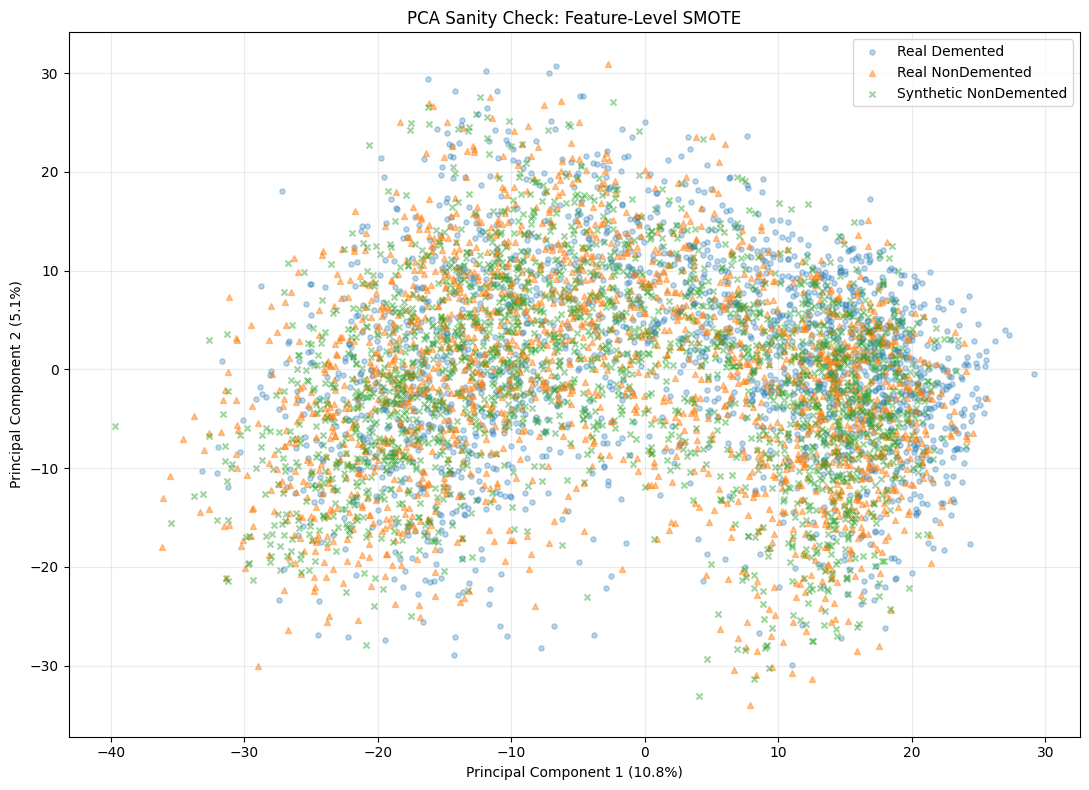

In [14]:
from sklearn.decomposition import PCA

PCA_SAMPLES_PER_GROUP = 2000
rng = np.random.default_rng(SEED)

real_0 = X_train_scaled[y_train == 0]
real_1 = X_train_scaled[y_train == 1]

real_0_indices = rng.choice(
    len(real_0), PCA_SAMPLES_PER_GROUP, replace=False
)
real_1_indices = rng.choice(
    len(real_1), PCA_SAMPLES_PER_GROUP, replace=False
)
synthetic_indices = rng.choice(
    len(synthetic_features),
    PCA_SAMPLES_PER_GROUP,
    replace=False
)

pca = PCA(
    n_components=2,
    svd_solver="randomized",
    random_state=SEED
)

print("Fitting PCA on original training embeddings...")
pca.fit(X_train_scaled)

real_0_pca = pca.transform(real_0[real_0_indices])
real_1_pca = pca.transform(real_1[real_1_indices])
synthetic_pca = pca.transform(
    synthetic_features[synthetic_indices]
)

print(
    "Explained variance:",
    round(pca.explained_variance_ratio_.sum(), 4)
)

plt.figure(figsize=(11, 8))

plt.scatter(
    real_1_pca[:, 0],
    real_1_pca[:, 1],
    s=14,
    alpha=0.30,
    label="Real Demented",
    marker="o"
)

plt.scatter(
    real_0_pca[:, 0],
    real_0_pca[:, 1],
    s=18,
    alpha=0.45,
    label="Real NonDemented",
    marker="^"
)

plt.scatter(
    synthetic_pca[:, 0],
    synthetic_pca[:, 1],
    s=18,
    alpha=0.45,
    label="Synthetic NonDemented",
    marker="x"
)

plt.xlabel(
    f"Principal Component 1 "
    f"({pca.explained_variance_ratio_[0]:.1%})"
)
plt.ylabel(
    f"Principal Component 2 "
    f"({pca.explained_variance_ratio_[1]:.1%})"
)
plt.title("PCA Sanity Check: Feature-Level SMOTE")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [15]:
CLASSIFIER_BATCH_SIZE = 32
MAX_EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 1e-4

train_feature_ds = (
    tf.data.Dataset
    .from_tensor_slices((
        X_train_smote,
        y_train_smote.astype(np.float32)
    ))
    .shuffle(
        len(y_train_smote),
        seed=SEED,
        reshuffle_each_iteration=True
    )
    .batch(CLASSIFIER_BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

validation_feature_ds = (
    tf.data.Dataset
    .from_tensor_slices((
        X_validation_scaled,
        y_validation.astype(np.float32)
    ))
    .batch(CLASSIFIER_BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_feature_ds = (
    tf.data.Dataset
    .from_tensor_slices((
        X_test_scaled,
        y_test.astype(np.float32)
    ))
    .batch(CLASSIFIER_BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

feature_batch, label_batch = next(iter(train_feature_ds))

print("Feature batch shape:", feature_batch.shape)
print("Label batch shape:", label_batch.shape)
print("Class counts in first batch:",
      Counter(label_batch.numpy()))

print("Training batches:", len(train_feature_ds))
print("Validation batches:", len(validation_feature_ds))
print("Test batches:", len(test_feature_ds))

print("\nMaximum epochs:", MAX_EPOCHS)
print("Patience:", PATIENCE)
print("Learning rate:", LEARNING_RATE)
print("Class weights: Disabled")
print("Focal class balancing: Disabled")

Feature batch shape: (32, 2048)
Label batch shape: (32,)
Class counts in first batch: Counter({np.float32(0.0): 16, np.float32(1.0): 16})
Training batches: 1365
Validation batches: 207
Test batches: 207

Maximum epochs: 30
Patience: 5
Learning rate: 0.0001
Class weights: Disabled
Focal class balancing: Disabled


In [16]:
FOCAL_GAMMA = 2.0

with strategy.scope():
    classifier_inputs = tf.keras.Input(
        shape=(2048,),
        name="resnet50_embedding"
    )

    classifier_outputs = tf.keras.layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32",
        name="binary_prediction"
    )(classifier_inputs)

    feature_classifier = tf.keras.Model(
        classifier_inputs,
        classifier_outputs,
        name="ResNet50_Feature_SMOTE_Focal"
    )

    focal_loss = tf.keras.losses.BinaryFocalCrossentropy(
        gamma=FOCAL_GAMMA,
        apply_class_balancing=False,
        from_logits=False
    )

    feature_classifier.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss=focal_loss,
        metrics=["accuracy"]
    )

print("Classifier parameters:",
      feature_classifier.count_params())
print("Focal gamma:", FOCAL_GAMMA)
print("Focal class balancing: Disabled")
print("Output activation: Sigmoid")

feature_classifier.summary()

Classifier parameters: 2049
Focal gamma: 2.0
Focal class balancing: Disabled
Output activation: Sigmoid


Model: "ResNet50_Feature_SMOTE_Focal"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50_embedding (InputLayer) │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ binary_prediction (Dense)       │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,049 (8.00 KB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
classifier_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/resnet50_feature_smote_focal_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

history = feature_classifier.fit(
    train_feature_ds,
    validation_data=validation_feature_ds,
    epochs=MAX_EPOCHS,
    callbacks=classifier_callbacks,
    verbose=1
)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

In [18]:
best_loss_epoch = np.argmin(
    history.history["val_loss"]
) + 1

best_accuracy_epoch = np.argmax(
    history.history["val_accuracy"]
) + 1

print("Epochs completed:", len(history.history["loss"]))
print("Best validation-loss epoch:", best_loss_epoch)
print("Best validation-accuracy epoch:", best_accuracy_epoch)

print("Best validation loss:",
      round(min(history.history["val_loss"]), 4))
print("Highest validation accuracy:",
      round(max(history.history["val_accuracy"]), 4))

print(
    "Validation accuracy at restored epoch:",
    round(
        history.history["val_accuracy"][
            best_loss_epoch - 1
        ],
        4
    )
)

Epochs completed: 28
Best validation-loss epoch: 23
Best validation-accuracy epoch: 22
Best validation loss: 0.0812
Highest validation accuracy: 0.8618
Validation accuracy at restored epoch: 0.8614


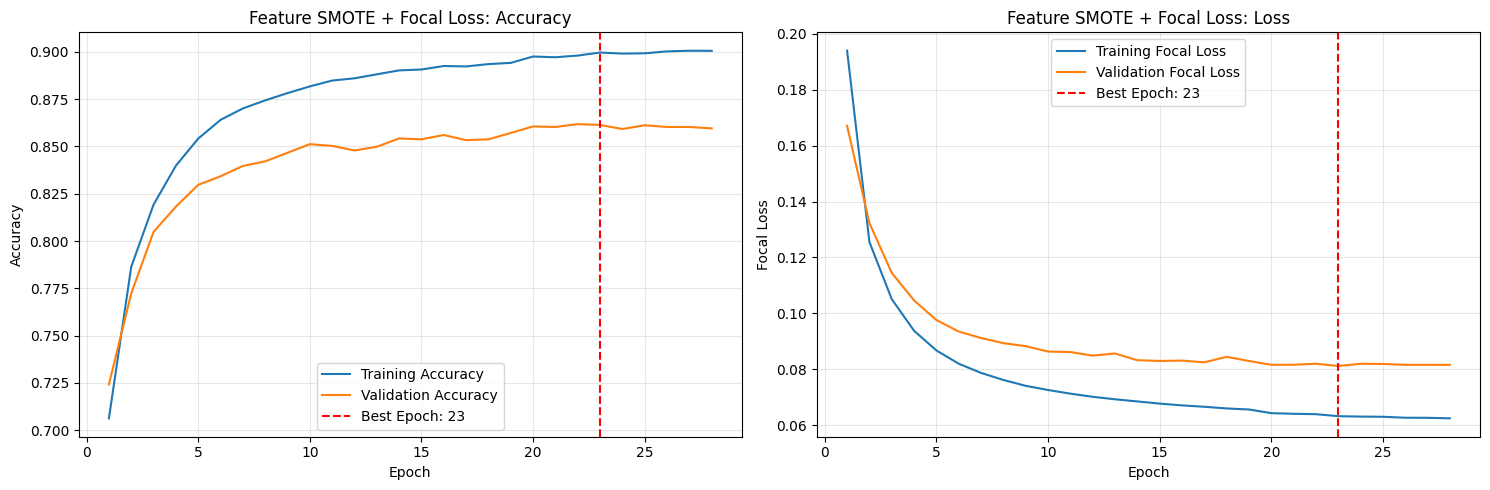

In [19]:
epochs = range(1, len(history.history["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(
    epochs,
    history.history["accuracy"],
    label="Training Accuracy"
)
axes[0].plot(
    epochs,
    history.history["val_accuracy"],
    label="Validation Accuracy"
)
axes[0].axvline(
    best_loss_epoch,
    color="red",
    linestyle="--",
    label=f"Best Epoch: {best_loss_epoch}"
)
axes[0].set_title("Feature SMOTE + Focal Loss: Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    epochs,
    history.history["loss"],
    label="Training Focal Loss"
)
axes[1].plot(
    epochs,
    history.history["val_loss"],
    label="Validation Focal Loss"
)
axes[1].axvline(
    best_loss_epoch,
    color="red",
    linestyle="--",
    label=f"Best Epoch: {best_loss_epoch}"
)
axes[1].set_title("Feature SMOTE + Focal Loss: Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Focal Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
test_focal_loss, test_accuracy = feature_classifier.evaluate(
    test_feature_ds,
    verbose=1
)

print("Test Focal Loss:", round(test_focal_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8633 - loss: 0.0838
Test Focal Loss: 0.0838
Test Accuracy: 0.8633


In [21]:
test_probabilities = feature_classifier.predict(
    test_feature_ds,
    verbose=1
).reshape(-1)

test_predictions = (
    test_probabilities >= 0.5
).astype(np.int32)

print("Test images:", len(y_test))
print("Probabilities:", len(test_probabilities))
print("Predictions:", len(test_predictions))

print("First probabilities:",
      np.round(test_probabilities[:10], 4))
print("First predictions:",
      test_predictions[:10])
print("First true labels:",
      y_test[:10])

207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Test images: 6600
Probabilities: 6600
Predictions: 6600
First probabilities: [0.8557 0.8511 0.8023 0.7701 0.8842 0.7802 0.8617 0.4984 0.9869 0.7182]
First predictions: [1 1 1 1 1 1 1 0 1 1]
First true labels: [1 1 1 1 1 1 1 0 1 1]


In [22]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_predictions
).ravel()

accuracy = accuracy_score(y_test, test_predictions)
balanced_accuracy = balanced_accuracy_score(
    y_test, test_predictions
)
precision = precision_score(y_test, test_predictions)
recall = recall_score(y_test, test_predictions)
specificity = tn / (tn + fp)
f1 = f1_score(y_test, test_predictions)
roc_auc = roc_auc_score(y_test, test_probabilities)
pr_auc = average_precision_score(
    y_test, test_probabilities
)

print("Test Focal Loss:", round(test_focal_loss, 4))
print("Accuracy:", round(accuracy, 4))
print("Balanced Accuracy:", round(balanced_accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall/Sensitivity:", round(recall, 4))
print("Specificity:", round(specificity, 4))
print("F1-score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))
print("PR-AUC:", round(pr_auc, 4))

Test Focal Loss: 0.0838
Accuracy: 0.8633
Balanced Accuracy: 0.8546
Precision: 0.9278
Recall/Sensitivity: 0.8754
Specificity: 0.8339
F1-score: 0.9008
ROC-AUC: 0.9339
PR-AUC: 0.97


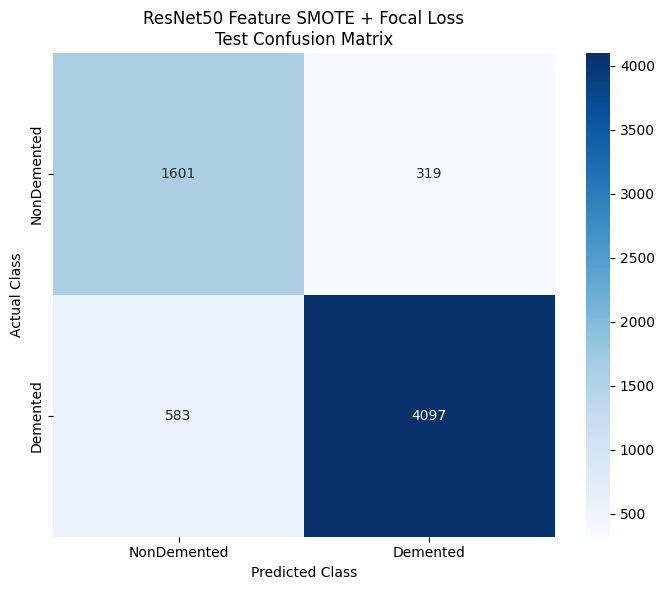

In [23]:
cm = confusion_matrix(y_test, test_predictions)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NonDemented", "Demented"],
    yticklabels=["NonDemented", "Demented"]
)

plt.title(
    "ResNet50 Feature SMOTE + Focal Loss\n"
    "Test Confusion Matrix"
)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

In [24]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=["NonDemented", "Demented"],
        digits=4
    )
)

              precision    recall  f1-score   support

 NonDemented     0.7331    0.8339    0.7802      1920
    Demented     0.9278    0.8754    0.9008      4680

    accuracy                         0.8633      6600
   macro avg     0.8304    0.8546    0.8405      6600
weighted avg     0.8711    0.8633    0.8657      6600



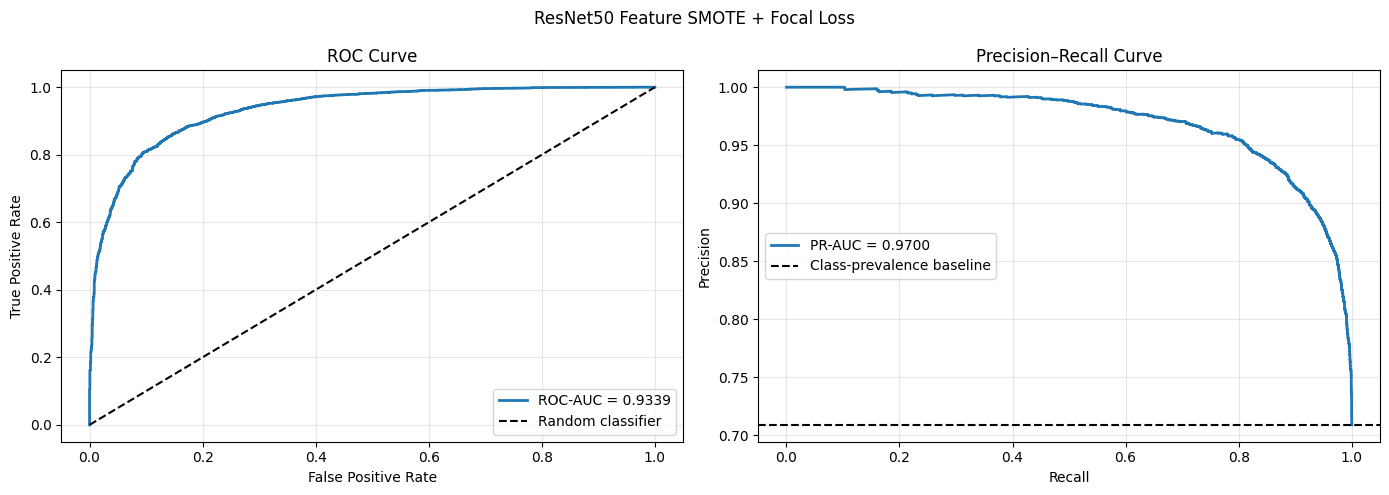

In [25]:
from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, _ = roc_curve(
    y_test,
    test_probabilities
)

pr_precision, pr_recall, _ = precision_recall_curve(
    y_test,
    test_probabilities
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ROC-AUC = {roc_auc:.4f}"
)
axes[0].plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random classifier"
)
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    pr_recall,
    pr_precision,
    linewidth=2,
    label=f"PR-AUC = {pr_auc:.4f}"
)
axes[1].axhline(
    y_test.mean(),
    color="black",
    linestyle="--",
    label="Class-prevalence baseline"
)
axes[1].set_title("Precision–Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("ResNet50 Feature SMOTE + Focal Loss")
plt.tight_layout()
plt.show()

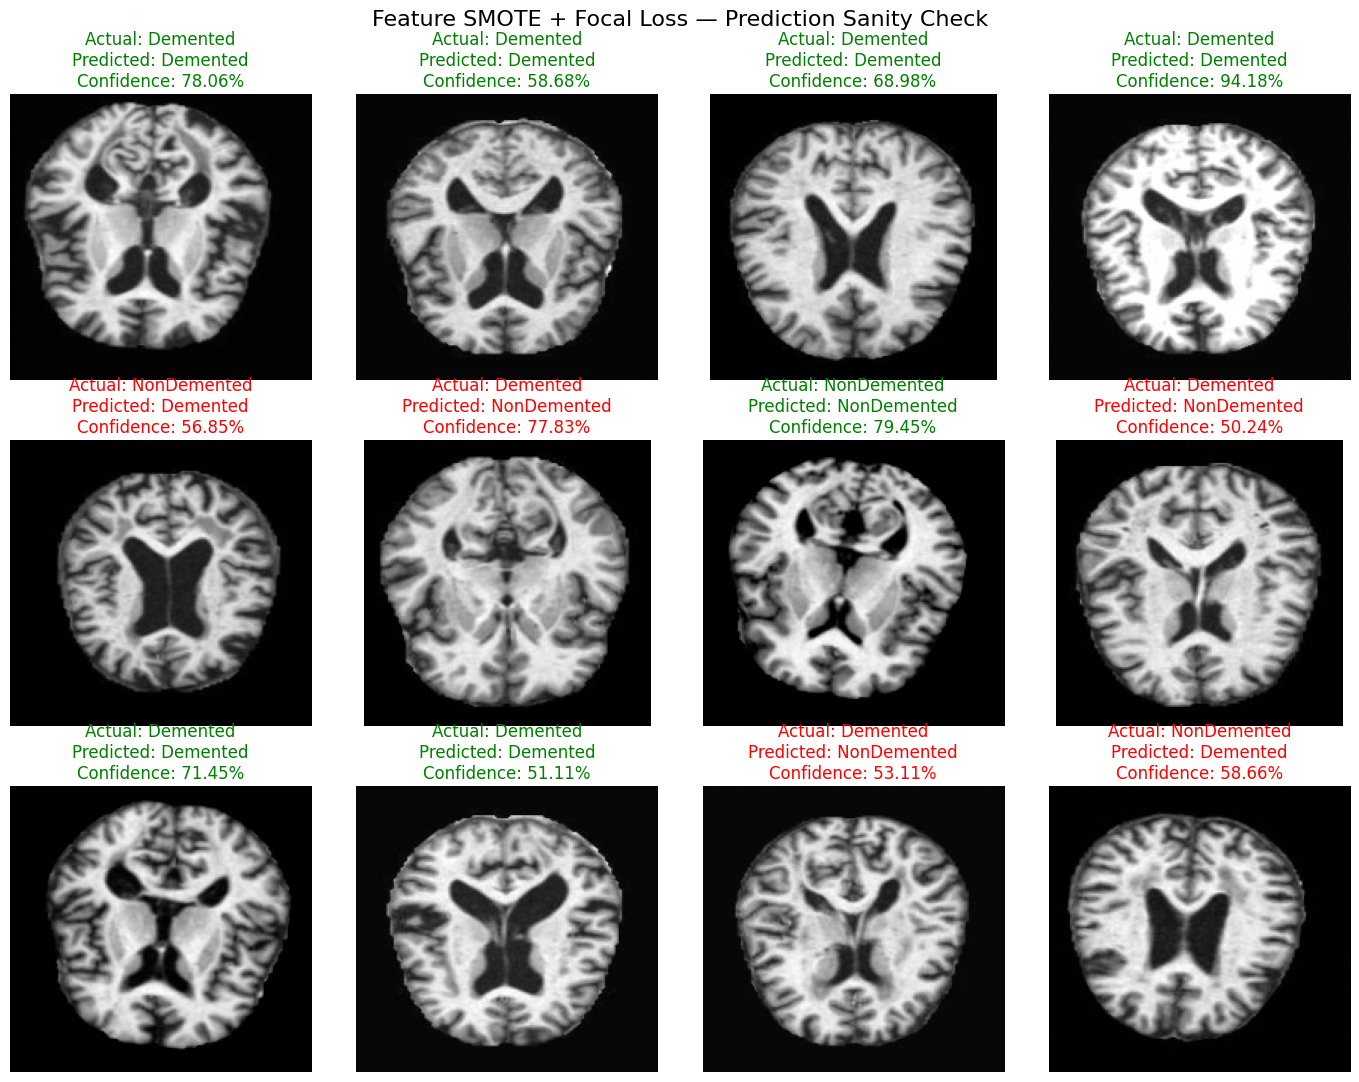

In [26]:
import cv2

rng = np.random.default_rng(SEED + 1)
display_indices = rng.choice(
    len(test_df),
    size=12,
    replace=False
)

fig, axes = plt.subplots(3, 4, figsize=(14, 11))

for axis, index in zip(axes.flat, display_indices):
    image = cv2.imread(
        test_df.iloc[index]["filepath"],
        cv2.IMREAD_GRAYSCALE
    )

    actual = (
        "Demented" if y_test[index] == 1
        else "NonDemented"
    )
    predicted = (
        "Demented" if test_predictions[index] == 1
        else "NonDemented"
    )

    probability = test_probabilities[index]
    confidence = (
        probability if test_predictions[index] == 1
        else 1.0 - probability
    )

    correct = y_test[index] == test_predictions[index]

    axis.imshow(image, cmap="gray")
    axis.set_title(
        f"Actual: {actual}\n"
        f"Predicted: {predicted}\n"
        f"Confidence: {confidence:.2%}",
        color="green" if correct else "red"
    )
    axis.axis("off")

plt.suptitle(
    "Feature SMOTE + Focal Loss — Prediction Sanity Check",
    fontsize=16
)
plt.tight_layout()
plt.show()

In [27]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall/Sensitivity",
        "Specificity",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ],

    "Feature SMOTE + BCE": [
        0.8655,
        0.8597,
        0.9325,
        0.8735,
        0.8458,
        0.9020,
        0.9339,
        0.9701
    ],

    "Feature SMOTE + Focal": [
        accuracy,
        balanced_accuracy,
        precision,
        recall,
        specificity,
        f1,
        roc_auc,
        pr_auc
    ]
})

comparison["Difference"] = (
    comparison["Feature SMOTE + Focal"] -
    comparison["Feature SMOTE + BCE"]
)

display(comparison.round(4))

,Metric,Feature SMOTE + BCE,Feature SMOTE + Focal,Difference
0,Accuracy,0.8655,0.8633,-0.0022
1,Balanced Accuracy,0.8597,0.8546,-0.0051
2,Precision,0.9325,0.9278,-0.0047
3,Recall/Sensitivity,0.8735,0.8754,0.0019
4,Specificity,0.8458,0.8339,-0.0119
5,F1-score,0.9020,0.9008,-0.0012
6,ROC-AUC,0.9339,0.9339,-0.0000
7,PR-AUC,0.9701,0.9700,-0.0001


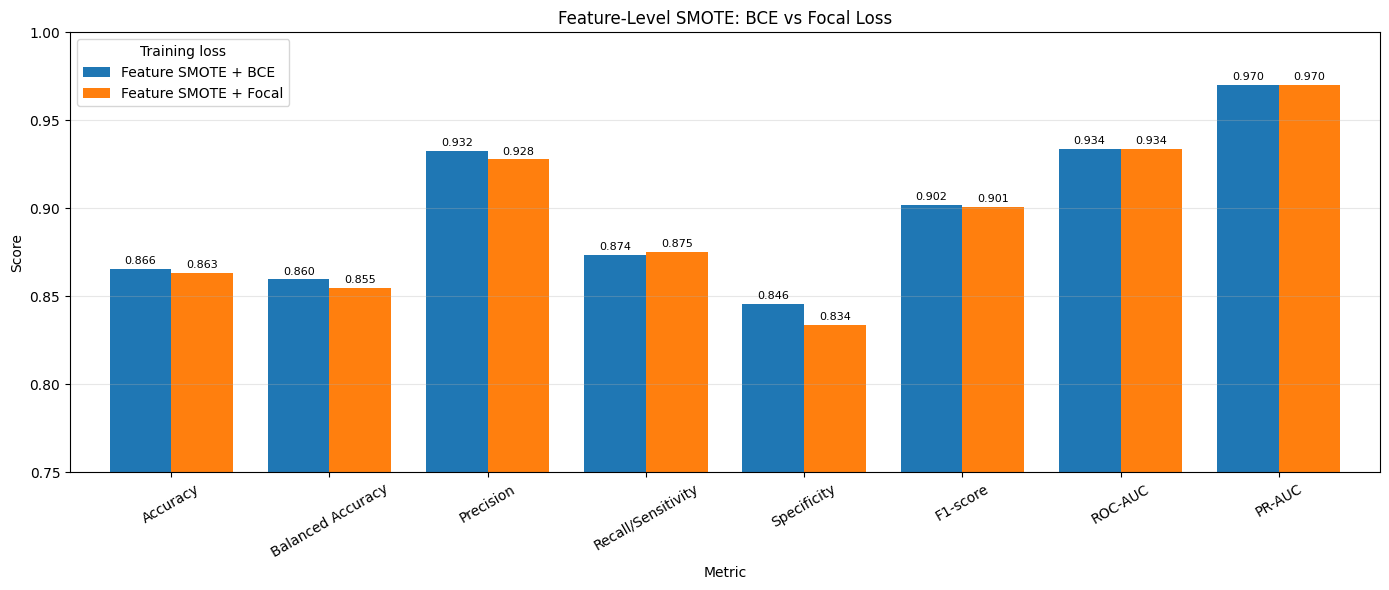

In [28]:
plot_data = comparison.drop(
    columns="Difference"
).set_index("Metric")

ax = plot_data.plot(
    kind="bar",
    figsize=(14, 6),
    width=0.78
)

ax.set_title("Feature-Level SMOTE: BCE vs Focal Loss")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_ylim(0.75, 1.0)
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=2,
        fontsize=8
    )

plt.legend(title="Training loss")
plt.tight_layout()
plt.show()

In [29]:
results = pd.DataFrame([{
    "Experiment": "ResNet50 Feature SMOTE + Focal Loss",
    "Focal Gamma": FOCAL_GAMMA,
    "Focal Class Balancing": False,
    "Test Focal Loss": test_focal_loss,
    "Accuracy": accuracy,
    "Balanced Accuracy": balanced_accuracy,
    "Precision": precision,
    "Recall": recall,
    "Specificity": specificity,
    "F1-score": f1,
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc
}])

results.to_csv(
    "/kaggle/working/resnet50_feature_smote_focal_results.csv",
    index=False
)

pd.DataFrame(history.history).to_csv(
    "/kaggle/working/resnet50_feature_smote_focal_history.csv",
    index=False
)

prediction_results = test_df.copy()
prediction_results["probability"] = test_probabilities
prediction_results["prediction"] = test_predictions
prediction_results["correct"] = (
    y_test == test_predictions
)

prediction_results.to_csv(
    "/kaggle/working/resnet50_feature_smote_focal_predictions.csv",
    index=False
)

comparison.to_csv(
    "/kaggle/working/feature_smote_loss_comparison.csv",
    index=False
)

joblib.dump(
    pca,
    "/kaggle/working/feature_smote_pca.joblib"
)

feature_extractor.save(
    "/kaggle/working/resnet50_feature_extractor.keras"
)

display(results.round(4))
print("All feature-SMOTE focal-loss files saved.")

,Experiment,Focal Gamma,Focal Class Balancing,Test Focal Loss,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,PR-AUC
0,ResNet50 Feature SMOTE + Focal Loss,2.0,False,0.0838,0.8633,0.8546,0.9278,0.8754,0.8339,0.9008,0.9339,0.97


All feature-SMOTE focal-loss files saved.
